<a href="https://colab.research.google.com/github/pandeyp84/Deep-Learning-Tutorials/blob/main/Object_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

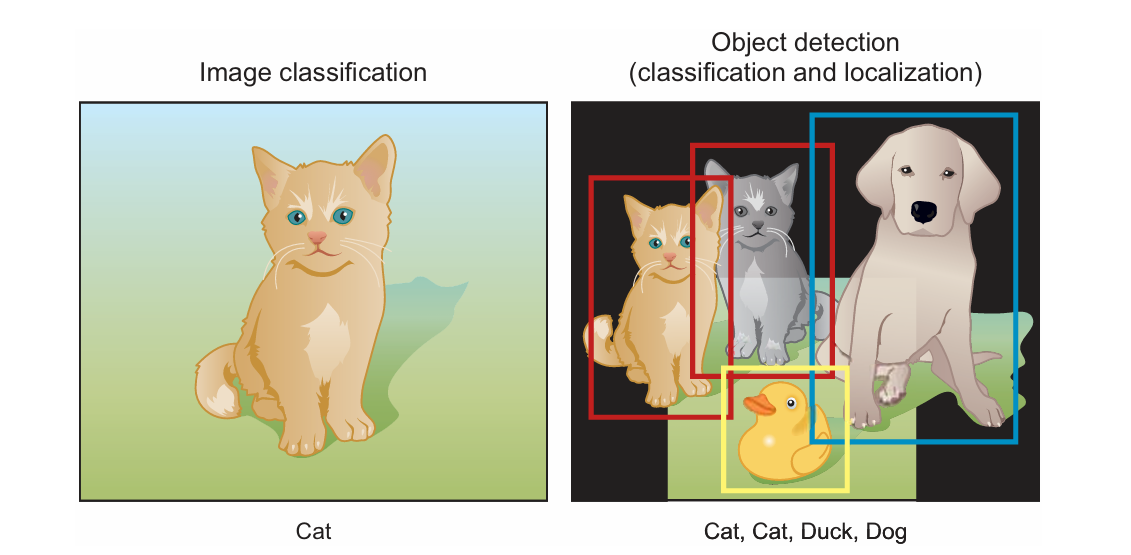

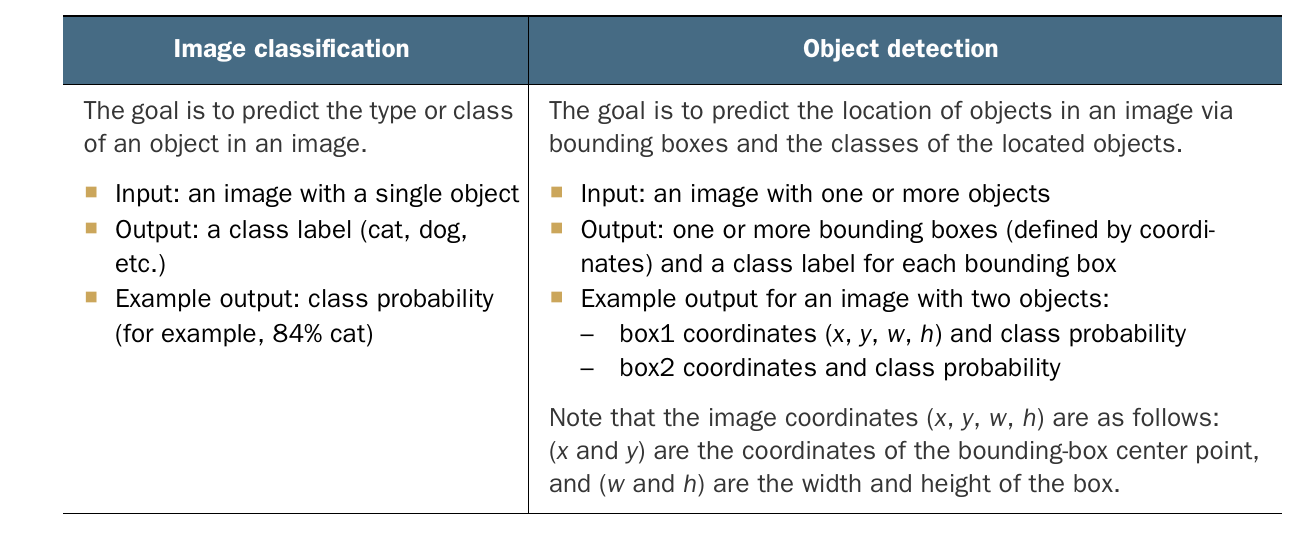

Typically, an object detection framework has four components:

  

1.   Region proposal — An algorithm or a DL model is used to generate regions of
 interest (RoIs) to be further processed by the system.

 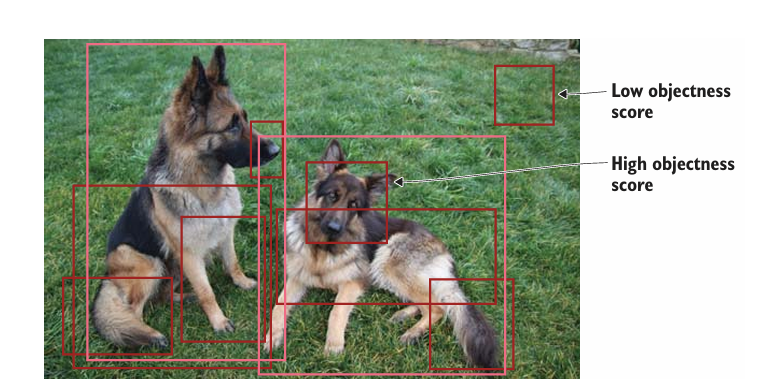

2.   Feature extraction and network predictions — Visual features are extracted for each
 of the bounding boxes.

 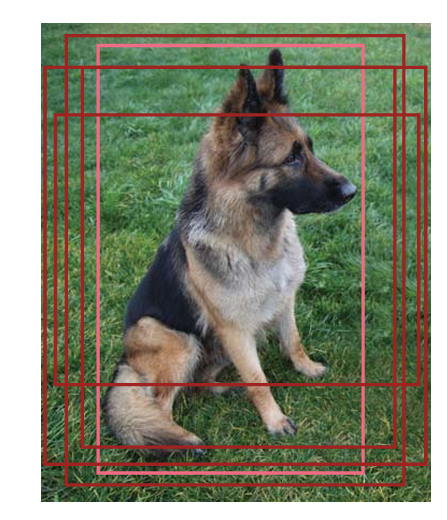








 3. Non-maximum suppression (NMS) — In this step, the model has likely found multi
ple bounding boxes for the same object.


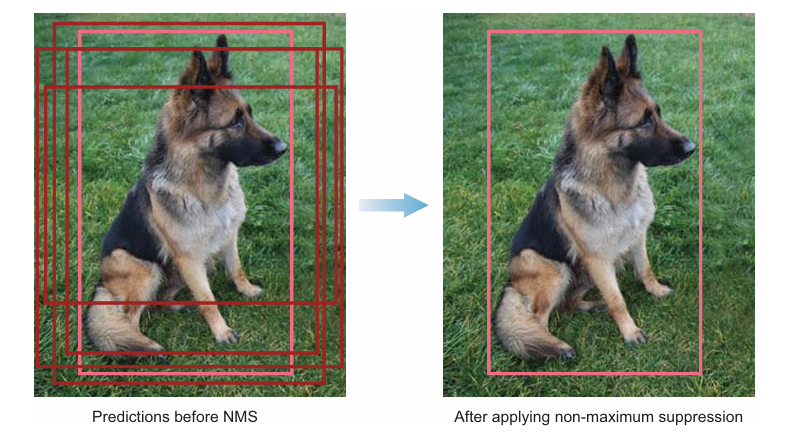

4. Evaluation metrics — Object detection systems have their own
 metrics to evaluate their detection performance  like mean average precision (mAP), precision-recall
 curve (PR curve), and intersection over union (IoU).



### RCNN

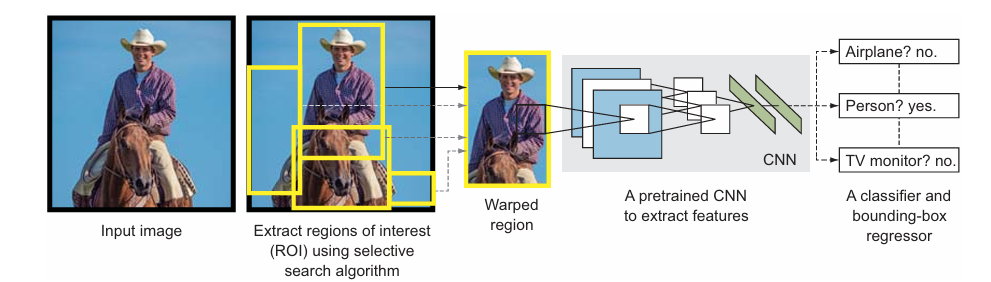

### ROI

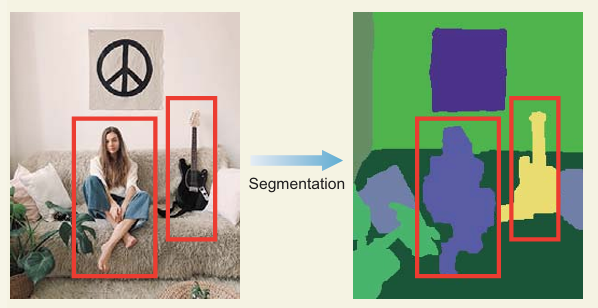



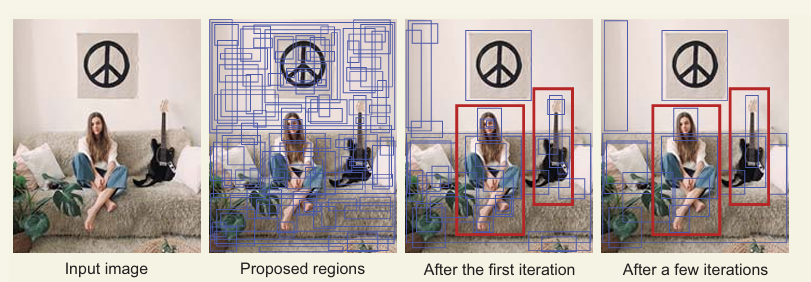

In [ ]:
!pip install selectivesearch


  Preparing metadata (setup.py) ... done
  Created wheel for selectivesearch: filename=selectivesearch-0.4-py3-none-any.whl size=4336 sha256=4b76dd81294a5b93182119287e7f2e9f770c86278f6038e63d4682521fca2b6d
  Stored in directory: /root/.cache/pip/wheels/7f/9b/c7/58b71f1e9fe4aa0ef8affd1c673f8818bc22a5091ea8cbbe93
Successfully built selectivesearch


In [ ]:
!unzip archive.zip

unzip:  cannot find or open archive.zip, archive.zip.zip or archive.zip.ZIP.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import random
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import selectivesearch
import tensorflow as tf

# -----------------------------
# CONFIG - change these paths
# -----------------------------
IMAGES_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"         # e.g. "smallvocx/images"
ANNOTATIONS_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/Annotations"  # e.g. "smallvocx/annotations"
OUTPUT_DIR = "./rcnn_outputs"                    # where detection images and models are saved
RANDOM_SEED = 123
TRAIN_COUNT = 10   # use 10 images for training
# -----------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# -----------------------------
# Utility: parse VOC XML
# -----------------------------
def parse_voc_xml(xml_path):
    """Return list of bounding boxes in (x,y,w,h) and labels as strings."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    if size is not None:
        width = int(size.find('width').text)
        height = int(size.find('height').text)
    else:
        # fallback: read image if size missing
        width = height = None

    boxes = []
    labels = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        b = obj.find('bndbox')
        xmin = int(float(b.find('xmin').text))
        ymin = int(float(b.find('ymin').text))
        xmax = int(float(b.find('xmax').text))
        ymax = int(float(b.find('ymax').text))
        boxes.append((xmin, ymin, xmax - xmin, ymax - ymin))
        labels.append(name)
    return boxes, labels, (width, height)

# -----------------------------
# Region proposals: Selective Search
# -----------------------------
def get_region_proposals(image, min_area=1500):
    """Return list of (x,y,w,h) proposals from selective search"""
    img_lbl, regions = selectivesearch.selective_search(
        image, scale=500, sigma=0.9, min_size=10
    )
    props = []
    for r in regions:
        x, y, w, h = r['rect']
        if w == 0 or h == 0:
            continue
        # filter tiny regions
        if w * h < min_area:
            continue
        # keep within image
        if x < 0 or y < 0:
            continue
        props.append((x, y, w, h))
    # remove duplicates
    props = list(dict.fromkeys(props))
    return props

# -----------------------------
# Helpers: IoU, encoding, apply regression
# -----------------------------
def compute_iou(boxA, boxB):
    ax, ay, aw, ah = boxA
    bx, by, bw, bh = boxB
    xA = max(ax, bx)
    yA = max(ay, by)
    xB = min(ax + aw, bx + bw)
    yB = min(ay + ah, by + bh)
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    inter = interW * interH
    areaA = aw * ah
    areaB = bw * bh
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def encode_bbox(proposal, gt):
    """Encode target offsets (tx,ty,tw,th) for proposal -> gt"""
    px, py, pw, ph = proposal
    gx, gy, gw, gh = gt
    tx = (gx - px) / pw
    ty = (gy - py) / ph
    tw = np.log(gw / pw)
    th = np.log(gh / ph)
    return np.array([tx, ty, tw, th], dtype=np.float32)

def apply_regression(proposal, pred):
    """Apply predicted offsets to proposal to get refined box"""
    px, py, pw, ph = proposal
    tx, ty, tw, th = pred
    gx = px + tx * pw
    gy = py + ty * ph
    gw = pw * np.exp(tw)
    gh = ph * np.exp(th)
    return [int(round(gx)), int(round(gy)), int(round(gw)), int(round(gh))]

# -----------------------------
# Simple Non-Maximum Suppression
# -----------------------------
def nms(boxes, scores, iou_thresh=0.3):
    if len(boxes) == 0:
        return []
    boxes_arr = np.array(boxes)
    scores_arr = np.array(scores)
    x1 = boxes_arr[:,0]
    y1 = boxes_arr[:,1]
    x2 = boxes_arr[:,0] + boxes_arr[:,2]
    y2 = boxes_arr[:,1] + boxes_arr[:,3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores_arr.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-8)
        inds = np.where(ovr <= iou_thresh)[0]
        order = order[inds + 1]
    return keep



In [ ]:
# -----------------------------
# Build models
# -----------------------------
IMG_SIZE = 224

feature_extractor = tf.keras.applications.ResNet50(
    include_top=False, pooling='avg', weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# small heads on top of extracted features
cls_head = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(feature_extractor.output_shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')   # binary: object / background
])

bbox_head = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(feature_extractor.output_shape[1],)),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dense(4, activation='linear')    # tx, ty, tw, th
])

# compile (we'll compile before training with defaults)
cls_head.compile(optimizer='adam', loss='binary_crossentropy')
bbox_head.compile(optimizer='adam', loss='huber')

# -----------------------------
# Dataset loading + split
# -----------------------------
# collect basenames that have both image and xml
all_basenames = []
for fname in os.listdir(IMAGES_DIR):
    name, ext = os.path.splitext(fname)
    if ext.lower() not in ('.jpg', '.jpeg', '.png'):
        continue
    xml_path = os.path.join(ANNOTATIONS_DIR, name + '.xml')
    if os.path.exists(xml_path):
        all_basenames.append(name)

all_basenames = sorted(list(set(all_basenames)))
if len(all_basenames) < TRAIN_COUNT + 2:
    print("Warning: found", len(all_basenames), "images. Expected at least", TRAIN_COUNT + 2)

random.shuffle(all_basenames)
train_names = all_basenames[:TRAIN_COUNT]
test_names = all_basenames[TRAIN_COUNT: TRAIN_COUNT + 2]

print("TRAIN ({}):".format(len(train_names)), train_names)
print("TEST ({}):".format(len(test_names)), test_names)



94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
TRAIN (10): ['008600', '009313', '006265', '002591', '008651', '004313', '000630', '000614', '006676', '007846']
TEST (2): ['005516', '005958']


In [ ]:
# -----------------------------
# Prepare training data: gather features and labels from proposals across all training images
# -----------------------------
X_feats = []
y_cls = []
y_reg = []

def prepare_training_from_image(img_path, boxes_gt):
    """Process single image: generate proposals, compute features, derive labels"""
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise ValueError("Failed to read image: " + img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    proposals = get_region_proposals(img_rgb)

    for prop in proposals:
        x,y,w,h = prop
        # crop & resize
        x2 = x + w
        y2 = y + h
        # safety crop
        h_img, w_img = img_rgb.shape[:2]
        x = max(0, x); y = max(0, y); x2 = min(w_img, x2); y2 = min(h_img, y2)
        w = max(1, x2 - x); h = max(1, y2 - y)
        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0:
            continue
        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        crop = crop.astype('float32') / 255.0

        # extract feature
        feat = feature_extractor.predict(np.expand_dims(crop, 0), verbose=0)[0]

        # find best IoU among GT boxes
        best_iou = 0.0
        best_gt = None
        for gt in boxes_gt:
            iou = compute_iou(prop, gt)
            if iou > best_iou:
                best_iou = iou
                best_gt = gt

        label = 1 if best_iou >= 0.5 else 0
        reg_target = encode_bbox(prop, best_gt) if label == 1 else np.zeros(4, dtype=np.float32)

        X_feats.append(feat)
        y_cls.append(label)
        y_reg.append(reg_target)

# loop train images
print("\nPreparing features and targets from training images (this may take a while)...")
for name in train_names:
    img_path_jpg = os.path.join(IMAGES_DIR, name + '.jpg')
    img_path_png = os.path.join(IMAGES_DIR, name + '.png')
    img_path = img_path_jpg if os.path.exists(img_path_jpg) else img_path_png
    xml_path = os.path.join(ANNOTATIONS_DIR, name + '.xml')
    boxes, labels, _ = parse_voc_xml(xml_path)
    prepare_training_from_image(img_path, boxes)

X_feats = np.array(X_feats, dtype=np.float32)
y_cls = np.array(y_cls, dtype=np.float32)
y_reg = np.array(y_reg, dtype=np.float32)

print("Collected proposals/features:", X_feats.shape[0])
print("Positive samples:", int(y_cls.sum()), "Negative samples:", X_feats.shape[0] - int(y_cls.sum()))





Preparing features and targets from training images (this may take a while)...


/usr/local/lib/python3.12/dist-packages/skimage/feature/texture.py:385: UserWarning: Applying `local_binary_pattern` to floating-point images may give unexpected results when small numerical differences between adjacent pixels are present. It is recommended to use this function with images of integer dtype.
  warnings.warn(


Collected proposals/features: 704
Positive samples: 57 Negative samples: 647


In [ ]:
# -----------------------------
# Train classifier and regressor
# -----------------------------
# train classifier on all proposals
print("\nTraining classifier head...")
cls_head.fit(X_feats, y_cls, epochs=6, batch_size=32, verbose=2)

# train regressor only on positive samples
pos_idx = np.where(y_cls == 1)[0]
if len(pos_idx) > 0:
    print("\nTraining bbox regressor on positive samples (n={})...".format(len(pos_idx)))
    bbox_head.fit(X_feats[pos_idx], y_reg[pos_idx], epochs=8, batch_size=16, verbose=2)
else:
    print("No positive samples found (increase proposals or relax IoU). Skipping regressor training.")

#  save models
cls_head.save(os.path.join(OUTPUT_DIR, "rcnn_cls_head.keras"))
bbox_head.save(os.path.join(OUTPUT_DIR, "rcnn_bbox_head.keras"))
feature_extractor.save_weights(os.path.join(OUTPUT_DIR, "resnet50_fe.weights.h5"))


Training classifier head...
Epoch 1/6
22/22 - 2s - 108ms/step - loss: 0.4138
Epoch 2/6
22/22 - 0s - 6ms/step - loss: 0.2783
Epoch 3/6
22/22 - 0s - 6ms/step - loss: 0.2596
Epoch 4/6
22/22 - 0s - 6ms/step - loss: 0.2521
Epoch 5/6
22/22 - 0s - 6ms/step - loss: 0.2451
Epoch 6/6
22/22 - 0s - 5ms/step - loss: 0.2382

Training bbox regressor on positive samples (n=57)...
Epoch 1/8
4/4 - 3s - 677ms/step - loss: 0.1791
Epoch 2/8
4/4 - 0s - 48ms/step - loss: 0.1101
Epoch 3/8
4/4 - 0s - 65ms/step - loss: 0.0531
Epoch 4/8
4/4 - 0s - 66ms/step - loss: 0.0438
Epoch 5/8
4/4 - 0s - 45ms/step - loss: 0.0409
Epoch 6/8
4/4 - 0s - 26ms/step - loss: 0.0294
Epoch 7/8
4/4 - 0s - 57ms/step - loss: 0.0236
Epoch 8/8
4/4 - 1s - 134ms/step - loss: 0.0220


In [ ]:

# -----------------------------
# Detection on test images
# -----------------------------
print("\nRunning detection on test images...")
for name in test_names:
    img_path_jpg = os.path.join(IMAGES_DIR, name + '.jpg')
    img_path_png = os.path.join(IMAGES_DIR, name + '.png')
    img_path = img_path_jpg if os.path.exists(img_path_jpg) else img_path_png
    xml_path = os.path.join(ANNOTATIONS_DIR, name + '.xml')

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    proposals = get_region_proposals(img_rgb)

    boxes_out = []
    scores_out = []

    for prop in proposals:
        x,y,w,h = prop
        x2 = x + w; y2 = y + h
        h_img, w_img = img_rgb.shape[:2]
        x = max(0, x); y = max(0, y); x2 = min(w_img, x2); y2 = min(h_img, y2)
        w = max(1, x2 - x); h = max(1, y2 - y)
        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0:
            continue
        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        crop = crop.astype('float32') / 255.0
        feat = feature_extractor.predict(np.expand_dims(crop, 0), verbose=0)[0]

        score = float(cls_head.predict(np.expand_dims(feat, 0), verbose=0)[0][0])
        if score < 0.1:
            continue

        reg = bbox_head.predict(np.expand_dims(feat, 0), verbose=0)[0]
        refined = apply_regression(prop, reg)
        boxes_out.append(refined)
        scores_out.append(score)

    # apply NMS
    keep_idx = nms(boxes_out, scores_out, iou_thresh=0.3)
    keep_boxes = [boxes_out[i] for i in keep_idx]
    keep_scores = [scores_out[i] for i in keep_idx]

    # draw results on image
    out_img = img_bgr.copy()
    for (x,y,w,h), sc in zip(keep_boxes, keep_scores):
        cv2.rectangle(out_img, (x,y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(out_img, f"{sc:.2f}", (x, max(y-8, 10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    out_fname = os.path.join(OUTPUT_DIR, f"{name}_det.jpg")
    cv2.imwrite(out_fname, out_img)
    print("Saved detection image:", out_fname)

print("\nDone. Outputs (models + detections) are in:", OUTPUT_DIR)



Running detection on test images...
Saved detection image: ./rcnn_outputs/005516_det.jpg
Saved detection image: ./rcnn_outputs/005958_det.jpg

Done. Outputs (models + detections) are in: ./rcnn_outputs


In [ ]:
# -----------------------------
# Detection on test images
# -----------------------------
print("\nRunning detection on test images...")
for name in test_names:

    img_path_jpg = os.path.join(IMAGES_DIR, name + '.jpg')
    img_path_png = os.path.join(IMAGES_DIR, name + '.png')
    img_path = img_path_jpg if os.path.exists(img_path_jpg) else img_path_png

    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    proposals = get_region_proposals(img_rgb)

    boxes_out = []
    scores_out = []

    h_img, w_img = img_rgb.shape[:2]

    for prop in proposals:
        x,y,w,h = prop
        x2 = x+w; y2 = y+h

        # safe crop
        x = max(0, x); y = max(0, y)
        x2 = min(w_img, x2); y2 = min(h_img, y2)
        w = max(1, x2 - x); h = max(1, y2 - y)

        crop = img_rgb[y:y+h, x:x+w]
        if crop.size == 0:
            continue

        crop = cv2.resize(crop, (IMG_SIZE, IMG_SIZE))
        crop = crop.astype('float32') / 255.0

        feat = feature_extractor.predict(np.expand_dims(crop, 0), verbose=0)[0]

        # --------- FIX #1: Lower threshold ---------
        score = float(cls_head.predict(np.expand_dims(feat, 0), verbose=0)[0][0])
        if score < 0.15:
            continue

        reg = bbox_head.predict(np.expand_dims(feat, 0), verbose=0)[0]
        rx, ry, rw, rh = apply_regression(prop, reg)

        # --------- FIX #2: Clip refined box ---------
        rx = max(0, min(rx, w_img-1))
        ry = max(0, min(ry, h_img-1))
        rw = max(1, min(rw, w_img - rx))
        rh = max(1, min(rh, h_img - ry))

        boxes_out.append([rx, ry, rw, rh])
        scores_out.append(score)

    # NMS
    keep_idx = nms(boxes_out, scores_out, iou_thresh=0.3)
    keep_boxes = [boxes_out[i] for i in keep_idx]
    keep_scores = [scores_out[i] for i in keep_idx]

    # Draw
    out_img = img_bgr.copy()
    for (x,y,w,h), sc in zip(keep_boxes, keep_scores):
        cv2.rectangle(out_img, (x,y), (x+w, y+h), (0,255,0), 2)
        cv2.putText(out_img, f"{sc:.2f}", (x, y-8), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)

    out_path = os.path.join(OUTPUT_DIR, f"{name}_det.jpg")
    cv2.imwrite(out_path, out_img)
    print("Saved detection:", out_path)



Running detection on test images...
Saved detection: ./rcnn_outputs/005516_det.jpg
Saved detection: ./rcnn_outputs/005958_det.jpg


### Fast RCNN

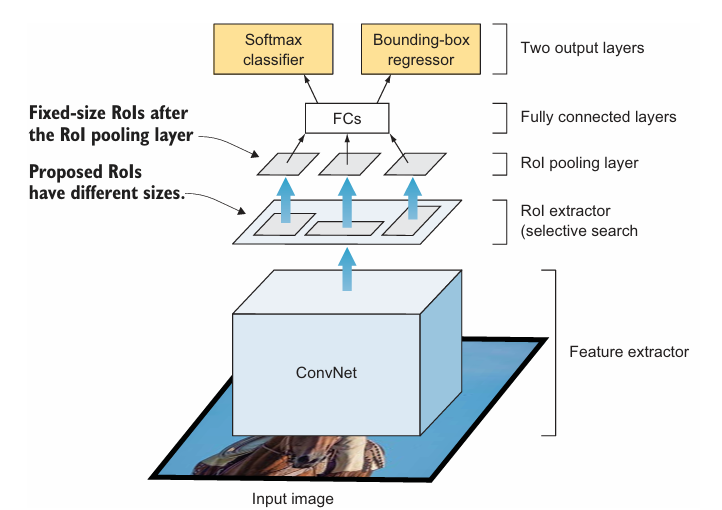

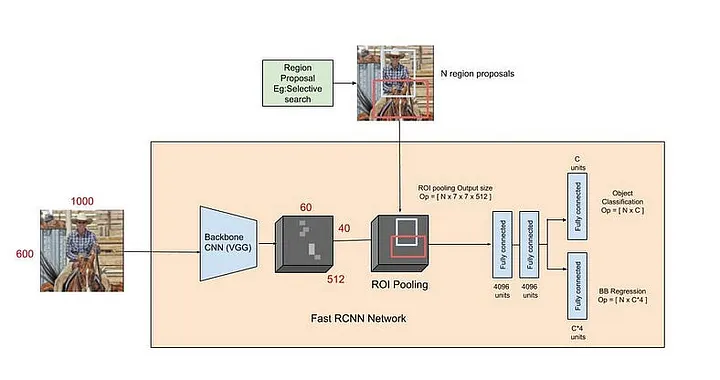

In [ ]:


import os
import random
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import selectivesearch
import tensorflow as tf

# -----------------------------
# CONFIG
# -----------------------------
IMAGES_DIR = "/content/VOC2007/JPEGImages"
ANNOTATIONS_DIR = "/content/VOC2007/Annotations"
OUTPUT_DIR = "./fastrcnn_outputs"
RANDOM_SEED = 123
TRAIN_COUNT = 10   # use 10 train, 2 test (adjust)
IMG_SIZE = 600     # longer side resize for input to backbone (keeps aspect ratio)
POOL_SIZE = (7, 7) # RoI pooling output
BATCH_PER_IMAGE = 128  # proposals sampled per image for training
POSITIVE_IOU = 0.5
NEGATIVE_IOU = 0.1
# -----------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)

# -----------------------------
# Utilities: parse VOC XML
# -----------------------------
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    labels = []
    size = root.find('size')
    if size is not None:
        width = int(size.find('width').text)
        height = int(size.find('height').text)
    else:
        width = height = None
    for obj in root.findall('object'):
        name = obj.find('name').text
        b = obj.find('bndbox')
        xmin = int(float(b.find('xmin').text))
        ymin = int(float(b.find('ymin').text))
        xmax = int(float(b.find('xmax').text))
        ymax = int(float(b.find('ymax').text))
        boxes.append((xmin, ymin, xmax - xmin, ymax - ymin))
        labels.append(name)
    return boxes, labels, (width, height)

# -----------------------------
# Selective Search proposals
# -----------------------------
def get_region_proposals(image, min_area=500):
    img_lbl, regions = selectivesearch.selective_search(image, scale=500, sigma=0.9, min_size=10)
    props = []
    for r in regions:
        x, y, w, h = r['rect']
        if w == 0 or h == 0: continue
        if w * h < min_area: continue
        if x < 0 or y < 0: continue
        props.append((x, y, w, h))
    # deduplicate
    props = list(dict.fromkeys(props))
    return props

# -----------------------------
# IoU and encoding helpers
# -----------------------------
def compute_iou(boxA, boxB):
    ax, ay, aw, ah = boxA
    bx, by, bw, bh = boxB
    xA = max(ax, bx); yA = max(ay, by)
    xB = min(ax + aw, bx + bw); yB = min(ay + ah, by + bh)
    interW = max(0, xB - xA); interH = max(0, yB - yA)
    inter = interW * interH
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0

def encode_bbox(proposal, gt):
    px, py, pw, ph = proposal
    gx, gy, gw, gh = gt
    tx = (gx - px) / pw
    ty = (gy - py) / ph
    tw = np.log(gw / pw)
    th = np.log(gh / ph)
    return np.array([tx, ty, tw, th], dtype=np.float32)

def apply_regression(proposal, pred):
    px, py, pw, ph = proposal
    tx, ty, tw, th = pred
    gx = px + tx * pw
    gy = py + ty * ph
    gw = pw * np.exp(tw)
    gh = ph * np.exp(th)
    return [int(round(gx)), int(round(gy)), int(round(gw)), int(round(gh))]

# -----------------------------
# Backbone (shared convs)
# -----------------------------
IMG_NET_SHORT = 600  # used for resize: we resize so max side = IMG_NET_SHORT
def resize_keep_aspect(img, max_side=IMG_NET_SHORT):
    h, w = img.shape[:2]
    scale = max_side / max(h, w)
    new_w = int(round(w * scale)); new_h = int(round(h * scale))
    img_r = cv2.resize(img, (new_w, new_h))
    return img_r, scale

backbone = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', pooling=None, input_shape=(None, None, 3))
# We'll take the conv feature map from backbone output (C x Hf x Wf)
# Add a small global pooling later for classification/regression head input

# -----------------------------
# Heads: classifier (binary) + bbox regressor
# -----------------------------
# Input to heads: pooled features flattened
def make_heads(input_dim):
    # simple two-head MLP using Keras Functional is easier to use in training loops
    x_in = tf.keras.Input(shape=(input_dim,), name='feat_in')
    x = tf.keras.layers.Dense(1024, activation='relu')(x_in)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    cls_out = tf.keras.layers.Dense(1, activation='sigmoid', name='cls_out')(x)   # object/background
    reg_out = tf.keras.layers.Dense(4, activation='linear', name='reg_out')(x)
    model = tf.keras.Model(inputs=x_in, outputs=[cls_out, reg_out])
    return model

# We'll create heads after we know feature vector length (depend on pooling)
# But for simplicity, we'll compute pooled features shape dynamically at runtime

# -----------------------------
# Load dataset and split
# -----------------------------
basenames = []
for fname in os.listdir(IMAGES_DIR):
    name, ext = os.path.splitext(fname)
    if ext.lower() not in ('.jpg', '.jpeg', '.png'): continue
    xml_path = os.path.join(ANNOTATIONS_DIR, name + '.xml')
    if os.path.exists(xml_path):
        basenames.append(name)
basenames = sorted(list(set(basenames)))
random.shuffle(basenames)
train_names = basenames[:TRAIN_COUNT]
test_names = basenames[TRAIN_COUNT:TRAIN_COUNT+2]
print("Train:", train_names)
print("Test:", test_names)

# -----------------------------
# Utility: roi_pooling using feature map & normalized boxes
# tf.image.crop_and_resize works with normalized boxes relative to input tensor size.
# If input tensor is feature_map, boxes normalized relative to original image still work
# because normalized coordinate = y / image_h = (y * Hf/Himg)/Hf => same fraction.
# -----------------------------
def roi_pool(feature_map, boxes, box_image_indices, pool_size=POOL_SIZE):
    """
    feature_map: [batch, Hf, Wf, C]
    boxes: [N, 4] in normalized coordinates [y1, x1, y2, x2] relative to original image
    box_image_indices: [N] which image in batch each box belongs to
    returns: [N, pool_h, pool_w, C]
    """
    crops = tf.image.crop_and_resize(feature_map, boxes, box_image_indices, crop_size=pool_size)
    return crops

# -----------------------------
# Prepare training proposals/features across train images
# -----------------------------
proposal_features = []  # pooled features
proposal_labels = []    # 0/1
proposal_reg_targets = []  # 4-deltas

# We'll build heads after extracting one pooled feature to know flattened dim
one_head_created = False
heads_model = None

print("Preparing proposals and targets from training images...")
for name in train_names:
    # read and resize
    img_path_jpg = os.path.join(IMAGES_DIR, name + '.jpg')
    img_path_png = os.path.join(IMAGES_DIR, name + '.png')
    img_path = img_path_jpg if os.path.exists(img_path_jpg) else img_path_png
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        print("Skipping missing", img_path); continue
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized, scale = resize_keep_aspect(img_rgb, IMG_NET_SHORT)
    h_res, w_res = img_resized.shape[:2]

    # parse GT boxes and scale them
    xml_path = os.path.join(ANNOTATIONS_DIR, name + '.xml')
    boxes_gt, labels_gt, _ = parse_voc_xml(xml_path)
    boxes_gt_scaled = []
    for (x,y,w,h) in boxes_gt:
        boxes_gt_scaled.append((int(x*scale), int(y*scale), int(w*scale), int(h*scale)))

    # backbone forward to get feature map (batch size 1)
    img_input = np.expand_dims(img_resized.astype('float32')/255.0, axis=0)
    feat_map = backbone(img_input)  # shape (1, Hf, Wf, C)
    Hf, Wf = feat_map.shape[1], feat_map.shape[2]

    # proposals (selective search) on resized image
    proposals = get_region_proposals(img_resized, min_area=500)
    if len(proposals) == 0:
        continue

    # prepare normalized boxes for tf.crop_and_resize: y1,x1,y2,x2 normalized by resized image size
    norm_boxes = []
    box_indices = []
    labels_sample = []
    regs = []

    for prop in proposals:
        px, py, pw, ph = prop
        # clip
        x2 = min(px+pw, w_res); y2 = min(py+ph, h_res)
        if x2-px <= 0 or y2-py <=0: continue
        # find best iou vs GT
        best_iou = 0.0; best_gt = None
        for gt in boxes_gt_scaled:
            iou = compute_iou(prop, gt)
            if iou > best_iou:
                best_iou = iou; best_gt = gt
        label = 1 if best_iou >= POSITIVE_IOU else 0
        # optionally ignore low IoU between NEGATIVE_IOU and POSITIVE_IOU (here keep them as negative)
        tx = ty = tw = th = 0.0
        if label == 1:
            tx, ty, tw, th = encode_bbox(prop, best_gt)
        # normalized coords
        y1n = py / h_res; x1n = px / w_res; y2n = y2 / h_res; x2n = x2 / w_res
        norm_boxes.append([y1n, x1n, y2n, x2n])
        box_indices.append(0)
        labels_sample.append(label)
        regs.append([tx,ty,tw,th])

    if len(norm_boxes) == 0:
        continue

    # crop pooled features from feature map
    norm_boxes_tf = tf.constant(norm_boxes, dtype=tf.float32)
    box_indices_tf = tf.constant(box_indices, dtype=tf.int32)
    pooled = roi_pool(feat_map, norm_boxes_tf, box_indices_tf, pool_size=POOL_SIZE)  # [N, ph, pw, C]
    pooled_flat = tf.reshape(pooled, (pooled.shape[0], -1)).numpy()

    # collect samples; optionally subsample to limit memory
    for i in range(pooled_flat.shape[0]):
        proposal_features.append(pooled_flat[i])
        proposal_labels.append(labels_sample[i])
        proposal_reg_targets.append(regs[i])

    # optional: limit proposals per image to first 500 to control size
    if len(proposal_features) > 5000:
        break

proposal_features = np.array(proposal_features, dtype=np.float32)
proposal_labels = np.array(proposal_labels, dtype=np.float32)
proposal_reg_targets = np.array(proposal_reg_targets, dtype=np.float32)

print("Total proposals collected:", proposal_features.shape[0], "positives:", int(proposal_labels.sum()))

# -----------------------------
# Build heads now we know pooled dim
# -----------------------------
feat_dim = proposal_features.shape[1]
heads_model = make_heads(feat_dim)
heads_model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                    loss={'cls_out':'binary_crossentropy','reg_out':'huber'},
                    loss_weights={'cls_out':1.0, 'reg_out':1.0})

# -----------------------------
# Train heads
# -----------------------------
# train on all proposals (cheap). For regressor, loss on negatives will be small but could be masked in advanced training.
print("Training detection heads...")
heads_model.fit(proposal_features, {'cls_out':proposal_labels, 'reg_out':proposal_reg_targets},
                epochs=8, batch_size=32, verbose=2)

# save heads
heads_model.save(os.path.join(OUTPUT_DIR, "fastrcnn_heads.keras"))
backbone.save_weights(os.path.join(OUTPUT_DIR, "backbone_resnet50_wts.h5"))

# -----------------------------
# Detection on test images
# -----------------------------
print("\nRunning detection on test images...")
for name in test_names:
    img_path_jpg = os.path.join(IMAGES_DIR, name + '.jpg')
    img_path_png = os.path.join(IMAGES_DIR, name + '.png')
    img_path = img_path_jpg if os.path.exists(img_path_jpg) else img_path_png
    img_bgr = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized, scale = resize_keep_aspect(img_rgb, IMG_NET_SHORT)
    h_res, w_res = img_resized.shape[:2]
    feat_map = backbone(np.expand_dims(img_resized.astype('float32')/255.0, 0))
    proposals = get_region_proposals(img_resized, min_area=500)
    norm_boxes = []
    box_idx = []
    raw_props = []
    for prop in proposals:
        px,py,pw,ph = prop
        x2 = min(px+pw, w_res); y2 = min(py+ph, h_res)
        if x2-px<=0 or y2-py<=0: continue
        norm_boxes.append([py/h_res, px/w_res, y2/h_res, x2/w_res])
        box_idx.append(0)
        raw_props.append(prop)
    if len(norm_boxes)==0:
        continue
    pooled = roi_pool(feat_map, tf.constant(norm_boxes,dtype=tf.float32), tf.constant(box_idx), pool_size=POOL_SIZE)
    pooled_flat = tf.reshape(pooled, (pooled.shape[0], -1)).numpy()
    preds = heads_model.predict(pooled_flat, verbose=0)
    scores = preds[0].reshape(-1)
    deltas = preds[1]
    # filter by score threshold and apply regression
    keep_boxes = []
    keep_scores = []
    for i, s in enumerate(scores):
        if s < 0.5: continue
        refined = apply_regression(raw_props[i], deltas[i])
        # rescale back to original image coordinates (divide by scale)
        x,y,w,h = refined
        x = int(round(x/scale)); y=int(round(y/scale)); w=int(round(w/scale)); h=int(round(h/scale))
        keep_boxes.append((x,y,w,h)); keep_scores.append(float(s))
    # simple NMS
    def nms(boxes, scores, thresh=0.3):
        if not boxes: return []
        boxes_a = np.array(boxes); scores_a=np.array(scores)
        x1 = boxes_a[:,0]; y1=boxes_a[:,1]; x2=boxes_a[:,0]+boxes_a[:,2]; y2=boxes_a[:,1]+boxes_a[:,3]
        areas = (x2-x1)*(y2-y1); order = scores_a.argsort()[::-1]
        keep=[]
        while order.size>0:
            i=order[0]; keep.append(i)
            xx1=np.maximum(x1[i], x1[order[1:]]); yy1=np.maximum(y1[i], y1[order[1:]])
            xx2=np.minimum(x2[i], x2[order[1:]]); yy2=np.minimum(y2[i], y2[order[1:]])
            w=np.maximum(0, xx2-xx1); h=np.maximum(0, yy2-yy1)
            inter=w*h; ovr=inter/(areas[i]+areas[order[1:]]-inter+1e-8)
            inds=np.where(ovr<=thresh)[0]; order=order[inds+1]
        return keep
    keep_idx = nms(keep_boxes, keep_scores, thresh=0.3)
    out_img = img_bgr.copy()
    for i in keep_idx:
        x,y,w,h = keep_boxes[i]
        s = keep_scores[i]
        cv2.rectangle(out_img, (x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(out_img, f"{s:.2f}", (x, max(y-5,10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0),2)
    out_path = os.path.join(OUTPUT_DIR, f"{name}_fastrcnn_det.jpg")
    cv2.imwrite(out_path, out_img)
    print("Saved", out_path)

print("Fast R-CNN complete. Outputs in", OUTPUT_DIR)


FileNotFoundError: [Errno 2] No such file or directory: '/content/VOC2007/JPEGImages'

In [ ]:

import os
import random
import xml.etree.ElementTree as ET
import cv2
import numpy as np
import selectivesearch
import tensorflow as tf

# -----------------------------
# CONFIG - change these paths
# -----------------------------
IMAGES_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"         # e.g. "smallvocx/images"
ANNOTATIONS_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/Annotations"  # e.g. "smallvocx/annotations"
OUTPUT_DIR = "./rcnn_outputs"                    # where detection images and models are saved
RANDOM_SEED = 123
TRAIN_COUNT = 10   # use 10 images for training
# -----------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# -----------------------------
# Utility: parse VOC XML
# -----------------------------
def parse_voc_xml(xml_path):
    """Return list of bounding boxes in (x,y,w,h) and labels as strings."""
    tree = ET.parse(xml_path)
    root = tree.getroot()

    size = root.find('size')
    if size is not None:
        width = int(size.find('width').text)
        height = int(size.find('height').text)
    else:
        # fallback: read image if size missing
        width = height = None

    boxes = []
    labels = []
    for obj in root.findall('object'):
        name = obj.find('name').text
        b = obj.find('bndbox')
        xmin = int(float(b.find('xmin').text))
        ymin = int(float(b.find('ymin').text))
        xmax = int(float(b.find('xmax').text))
        ymax = int(float(b.find('ymax').text))
        boxes.append((xmin, ymin, xmax - xmin, ymax - ymin))
        labels.append(name)
    return boxes, labels, (width, height)

# -----------------------------
# Region proposals: Selective Search
# -----------------------------
def get_region_proposals(image, min_area=1500):
    """Return list of (x,y,w,h) proposals from selective search"""
    img_lbl, regions = selectivesearch.selective_search(
        image, scale=500, sigma=0.9, min_size=10
    )
    props = []
    for r in regions:
        x, y, w, h = r['rect']
        if w == 0 or h == 0:
            continue
        # filter tiny regions
        if w * h < min_area:
            continue
        # keep within image
        if x < 0 or y < 0:
            continue
        props.append((x, y, w, h))
    # remove duplicates
    props = list(dict.fromkeys(props))
    return props

# -----------------------------
# Helpers: IoU, encoding, apply regression
# -----------------------------
def compute_iou(boxA, boxB):
    ax, ay, aw, ah = boxA
    bx, by, bw, bh = boxB
    xA = max(ax, bx)
    yA = max(ay, by)
    xB = min(ax + aw, bx + bw)
    yB = min(ay + ah, by + bh)
    interW = max(0, xB - xA)
    interH = max(0, yB - yA)
    inter = interW * interH
    areaA = aw * ah
    areaB = bw * bh
    union = areaA + areaB - inter
    return inter / union if union > 0 else 0.0

def encode_bbox(proposal, gt):
    """Encode target offsets (tx,ty,tw,th) for proposal -> gt"""
    px, py, pw, ph = proposal
    gx, gy, gw, gh = gt
    tx = (gx - px) / pw
    ty = (gy - py) / ph
    tw = np.log(gw / pw)
    th = np.log(gh / ph)
    return np.array([tx, ty, tw, th], dtype=np.float32)

def apply_regression(proposal, pred):
    """Apply predicted offsets to proposal to get refined box"""
    px, py, pw, ph = proposal
    tx, ty, tw, th = pred
    gx = px + tx * pw
    gy = py + ty * ph
    gw = pw * np.exp(tw)
    gh = ph * np.exp(th)
    return [int(round(gx)), int(round(gy)), int(round(gw)), int(round(gh))]

# -----------------------------
# Simple Non-Maximum Suppression
# -----------------------------
def nms(boxes, scores, iou_thresh=0.3):
    if len(boxes) == 0:
        return []
    boxes_arr = np.array(boxes)
    scores_arr = np.array(scores)
    x1 = boxes_arr[:,0]
    y1 = boxes_arr[:,1]
    x2 = boxes_arr[:,0] + boxes_arr[:,2]
    y2 = boxes_arr[:,1] + boxes_arr[:,3]
    areas = (x2 - x1) * (y2 - y1)
    order = scores_arr.argsort()[::-1]
    keep = []
    while order.size > 0:
        i = order[0]
        keep.append(i)
        xx1 = np.maximum(x1[i], x1[order[1:]])
        yy1 = np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]])
        yy2 = np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0.0, xx2 - xx1)
        h = np.maximum(0.0, yy2 - yy1)
        inter = w * h
        ovr = inter / (areas[i] + areas[order[1:]] - inter + 1e-8)
        inds = np.where(ovr <= iou_thresh)[0]
        order = order[inds + 1]
    return keep



### FASTER RCNN

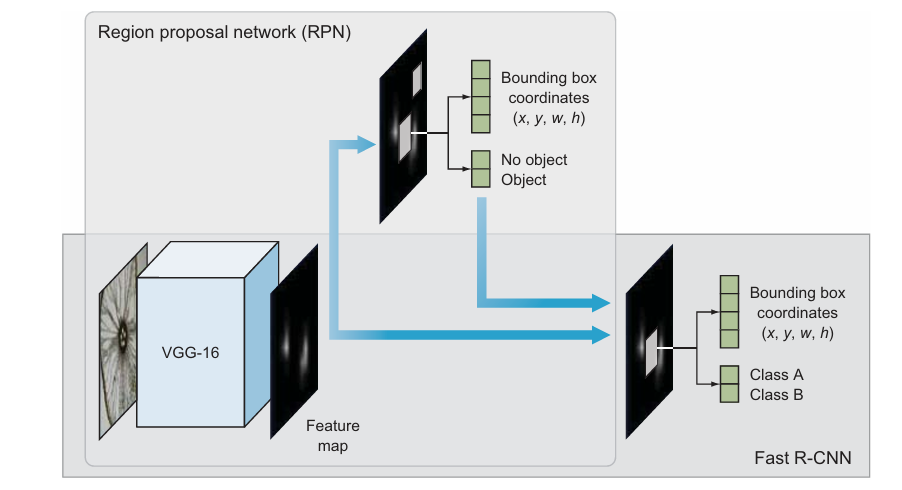

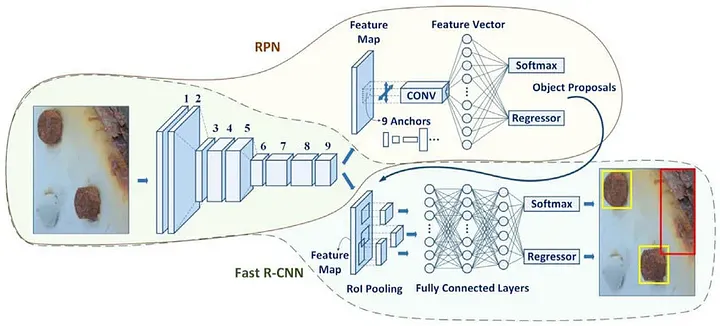

In [ ]:


import os, random, math
import xml.etree.ElementTree as ET
import cv2, numpy as np, tensorflow as tf

# -----------------------------
# CONFIG
# -----------------------------
IMAGES_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/JPEGImages"         # e.g. "smallvocx/images"
ANNOTATIONS_DIR = "/content/drive/MyDrive/e_Master/VOCtest_06-Nov-2007/VOCdevkit/VOC2007/Annotations"
OUTPUT_DIR = "./fasterrcnn_outputs"
RANDOM_SEED = 123
TRAIN_COUNT = 10
IMG_SHORT_SIDE = 600
POOL_SIZE = (7, 7)
ANCHOR_SCALES = [32, 64, 128]
ANCHOR_RATIOS = [0.5, 1, 2]
RPN_PRE_NMS_TOPN = 600
RPN_POST_NMS_TOPN = 200
RPN_NMS_THRESH = 0.7
POSITIVE_IOU = 0.7
NEGATIVE_IOU = 0.3
# -----------------------------
os.makedirs(OUTPUT_DIR, exist_ok=True)
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); tf.random.set_seed(RANDOM_SEED)

# -----------------------------
# Helpers: parse VOC XML, IoU, encode/apply deltas
# -----------------------------
def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path); root = tree.getroot()
    boxes=[]; labels=[]
    for obj in root.findall('object'):
        name = obj.find('name').text
        b = obj.find('bndbox')
        xmin = int(float(b.find('xmin').text)); ymin=int(float(b.find('ymin').text))
        xmax = int(float(b.find('xmax').text)); ymax=int(float(b.find('ymax').text))
        boxes.append((xmin, ymin, xmax-xmin, ymax-ymin)); labels.append(name)
    return boxes, labels

def compute_iou(boxA, boxB):
    ax, ay, aw, ah = boxA; bx, by, bw, bh = boxB
    xA = max(ax, bx); yA = max(ay, by)
    xB = min(ax+aw, bx+bw); yB = min(ay+ah, by+bh)
    interW=max(0, xB-xA); interH=max(0, yB-yA); inter=interW*interH
    union = aw*ah + bw*bh - inter
    return inter/union if union>0 else 0.0

def encode_deltas(anchors, gt):
    # anchors: (x,y,w,h), gt same: returns (tx,ty,tw,th)
    px,py,pw,ph = anchors; gx,gy,gw,gh=gt
    tx=(gx-px)/pw; ty=(gy-py)/ph; tw=np.log(gw/pw); th=np.log(gh/ph)
    return np.array([tx,ty,tw,th], dtype=np.float32)

def apply_deltas_to_anchors(anchors, deltas):
    px,py,pw,ph = anchors; tx,ty,tw,th = deltas
    gx = px + tx*pw; gy = py + ty*ph
    gw = pw * np.exp(tw); gh = ph * np.exp(th)
    return [int(round(gx)), int(round(gy)), int(round(gw)), int(round(gh))]

# -----------------------------
# Backbone
# -----------------------------
def resize_keep_aspect(img, short_side=IMG_SHORT_SIDE):
    h,w=img.shape[:2]; scale = short_side / min(h,w)
    new_w = int(round(w*scale)); new_h = int(round(h*scale))
    return cv2.resize(img, (new_w,new_h)), scale

backbone = tf.keras.applications.ResNet50(include_top=False, weights='imagenet', input_shape=(None,None,3))
# take output feature_map from backbone (C,Hf,Wf)

# -----------------------------
# Anchor generation on feature map grid
# -----------------------------
def generate_anchors_for_feature_map(feature_map_shape, feat_stride, scales=ANCHOR_SCALES, ratios=ANCHOR_RATIOS):
    """
    feature_map_shape: (Hf, Wf)
    feat_stride: spatial stride between original image and feature map (image / feature_map dims)
    returns: anchors list of (x_center, y_center, w, h) in image coordinates (center-based)
    But for simplicity we use (x, y, w, h) top-left width height representation here
    """
    Hf, Wf = feature_map_shape
    anchors=[]
    for i in range(Hf):
        for j in range(Wf):
            # center of anchor on image coordinates
            cy = (i + 0.5) * feat_stride
            cx = (j + 0.5) * feat_stride
            for s in scales:
                for r in ratios:
                    area = s * s
                    w = int(round(math.sqrt(area / r)))
                    h = int(round(w * r))
                    # top-left coords
                    x = int(round(cx - w/2)); y = int(round(cy - h/2))
                    anchors.append((x,y,w,h))
    return anchors

# -----------------------------
# RPN model definition
# -----------------------------
def build_rpn(num_anchors):
    """
    RPN over feature map: conv -> relu -> conv objectness + conv bbox
    num_anchors: number of anchors per spatial location
    """
    inp = tf.keras.Input(shape=(None,None,1024))  # assume backbone outputs channels >=1024 at chosen layer
    x = tf.keras.layers.Conv2D(512, (3,3), padding='same', activation='relu')(inp)
    obj = tf.keras.layers.Conv2D(num_anchors * 1, (1,1), padding='same')(x)  # objectness logits
    bbox = tf.keras.layers.Conv2D(num_anchors * 4, (1,1), padding='same')(x)  # bbox deltas
    model = tf.keras.Model(inputs=inp, outputs=[obj, bbox])
    return model

# For simplicity, we will take backbone output from layer 'conv4_block6_out' (C ~ 1024)
backbone_model = tf.keras.Model(inputs=backbone.input, outputs=backbone.get_layer('conv4_block6_out').output)
feat_channels = backbone_model.output_shape[-1]
num_anchors = len(ANCHOR_SCALES) * len(ANCHOR_RATIOS)
rpn_model = build_rpn(num_anchors)
rpn_optimizer = tf.keras.optimizers.Adam(1e-5)

# -----------------------------
# Simple NMS using numpy
# -----------------------------
def nms_numpy(boxes, scores, iou_threshold=0.3, top_k=300):
    if len(boxes)==0: return []
    boxes = np.array(boxes); scores=np.array(scores)
    order = scores.argsort()[::-1]
    keep=[]
    x1 = boxes[:,0]; y1=boxes[:,1]; x2=boxes[:,0]+boxes[:,2]; y2=boxes[:,1]+boxes[:,3]
    areas = (x2-x1)*(y2-y1)
    count=0
    while order.size>0 and count<top_k:
        i=order[0]; keep.append(i); count+=1
        xx1 = np.maximum(x1[i], x1[order[1:]]); yy1=np.maximum(y1[i], y1[order[1:]])
        xx2 = np.minimum(x2[i], x2[order[1:]]); yy2=np.minimum(y2[i], y2[order[1:]])
        w = np.maximum(0, xx2-xx1); h=np.maximum(0, yy2-yy1)
        inter = w*h
        ovr = inter/(areas[i]+areas[order[1:]]-inter+1e-8)
        inds = np.where(ovr <= iou_threshold)[0]
        order = order[inds+1]
    return keep

# -----------------------------
# Dataset
# -----------------------------
basenames=[]
for fname in os.listdir(IMAGES_DIR):
    name, ext = os.path.splitext(fname)
    if ext.lower() not in ('.jpg','.jpeg','.png'): continue
    if os.path.exists(os.path.join(ANNOTATIONS_DIR, name + '.xml')):
        basenames.append(name)
basenames=sorted(set(basenames))
random.shuffle(basenames)
train_names = basenames[:TRAIN_COUNT]
test_names = basenames[TRAIN_COUNT:TRAIN_COUNT+2]
print("Train:", train_names, "Test:", test_names)

# -----------------------------
# RPN training loop (very simplified)
# - For each image: forward backbone -> feature_map
# - Generate anchors (on feature_map grid using feat_stride)
# - Match anchors to GT boxes to create objectness labels (1/0) and bbox targets
# - Compute RPN losses and step optimizer
# -----------------------------
def get_feat_stride(img_resized, feat_map):
    # feat_map shape (1,Hf,Wf,C)
    Hf = feat_map.shape[1]; Wf=feat_map.shape[2]
    h_img = img_resized.shape[0]; w_img = img_resized.shape[1]
    # stride approximated as image_dim / feat_dim (use height)
    stride_h = h_img / Hf; stride_w = w_img / Wf
    # assume roughly equal
    return (stride_h + stride_w) / 2.0

print("TRAIN RPN (simplified)...")
for epoch in range(2):  # few epochs for demo
    for name in train_names:
        img_path = os.path.join(IMAGES_DIR, name + '.jpg')
        if not os.path.exists(img_path): img_path = os.path.join(IMAGES_DIR, name + '.png')
        img_bgr = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_resized, scale = resize_keep_aspect(img_rgb, IMG_SHORT_SIDE)
        boxes_gt, labels_gt = parse_voc_xml(os.path.join(ANNOTATIONS_DIR, name + '.xml'))
        boxes_gt_scaled = [(int(x*scale),int(y*scale),int(w*scale),int(h*scale)) for (x,y,w,h) in boxes_gt]
        # feature map
        feat_map = backbone_model(np.expand_dims(img_resized.astype('float32')/255.0,0))
        Hf,Wf = feat_map.shape[1], feat_map.shape[2]
        feat_stride = get_feat_stride(img_resized, feat_map)
        # anchors
        anchors = generate_anchors_for_feature_map((Hf,Wf), feat_stride, scales=ANCHOR_SCALES, ratios=ANCHOR_RATIOS)
        if len(anchors)==0: continue
        # match anchors to GT: assign positive if IoU >= POSITIVE_IOU, negative if IoU < NEGATIVE_IOU, else ignore
        labels = np.full(len(anchors), -1, dtype=np.int32) # -1 ignore, 0 negative, 1 positive
        bbox_targets = np.zeros((len(anchors),4), dtype=np.float32)
        for i, anc in enumerate(anchors):
            # find max IoU
            best_iou=0; best_gt=None
            for gt in boxes_gt_scaled:
                iou = compute_iou(anc, gt)
                if iou > best_iou:
                    best_iou=iou; best_gt=gt
            if best_iou >= POSITIVE_IOU:
                labels[i]=1
                bbox_targets[i]=encode_deltas(anc,best_gt)
            elif best_iou < NEGATIVE_IOU:
                labels[i]=0
            else:
                labels[i]=-1
        # sample balanced mini-batch of anchors for loss (e.g., 256)
        pos_idx = np.where(labels==1)[0]
        neg_idx = np.where(labels==0)[0]
        num_pos = min(32, len(pos_idx))
        num_neg = min(96, len(neg_idx))
        if len(pos_idx)>0:
            pos_sel = np.random.choice(pos_idx, num_pos, replace=False)
        else:
            pos_sel = np.array([], dtype=np.int32)
        if len(neg_idx)>0:
            neg_sel = np.random.choice(neg_idx, num_neg, replace=False)
        else:
            neg_sel = np.array([], dtype=np.int32)
        sel_idx = np.concatenate([pos_sel, neg_sel])
        if sel_idx.size == 0: continue
        # prepare mini-batch tensors
        # Compute RPN outputs predictions
        with tf.GradientTape() as tape:
            # run rpn on feature map (batch 1)
            obj_logits, bbox_preds = rpn_model(feat_map, training=True)  # obj_logits shape (1,Hf,Wf,num_anchors)
            # reshape to (N_anchors, )
            obj_logits_np = obj_logits.numpy().reshape(-1)
            bbox_preds_np = bbox_preds.numpy().reshape(-1,4)
            # compute losses on selected indices
            sel_obj_logits = obj_logits_np[sel_idx]
            sel_labels = labels[sel_idx]
            # objectness loss: binary crossentropy
            sel_obj_labels = sel_labels.astype(np.float32)
            obj_loss = tf.keras.losses.binary_crossentropy(sel_obj_labels, sel_obj_logits, from_logits=True)
            obj_loss = tf.reduce_mean(obj_loss)
            # bbox regression loss for positive anchors only
            if num_pos>0:
                sel_pos_idx = pos_sel
                pred_deltas = bbox_preds_np[sel_pos_idx]
                target_deltas = bbox_targets[sel_pos_idx]
                reg_loss = tf.reduce_mean(tf.keras.losses.Huber()(target_deltas, pred_deltas))
            else:
                reg_loss = 0.0
            total_loss = obj_loss + reg_loss
        grads = tape.gradient(total_loss, rpn_model.trainable_weights)
        rpn_optimizer.apply_gradients(zip(grads, rpn_model.trainable_weights))
        # logging small
    print("Epoch", epoch, "done.")

# -----------------------------
# Generate proposals from RPN (apply deltas to anchors, score by objectness, NMS)
# -----------------------------
def rpn_proposals_from_feature_map(feat_map, img_resized, top_n_pre=RPN_PRE_NMS_TOPN, top_n_post=RPN_POST_NMS_TOPN):
    Hf,Wf = feat_map.shape[1], feat_map.shape[2]
    feat_stride = (img_resized.shape[0] / Hf + img_resized.shape[1] / Wf)/2.0
    anchors = generate_anchors_for_feature_map((Hf,Wf), feat_stride, scales=ANCHOR_SCALES, ratios=ANCHOR_RATIOS)
    if len(anchors)==0: return []
    obj_logits, bbox_preds = rpn_model(feat_map, training=False)
    obj_scores = tf.sigmoid(tf.reshape(obj_logits, (-1,))).numpy()
    bbox_preds = tf.reshape(bbox_preds, (-1,4)).numpy()
    # select top pre-NMS by score
    order = obj_scores.argsort()[::-1][:top_n_pre]
    boxes = []
    scores = []
    for idx in order:
        anc = anchors[idx]
        pred = bbox_preds[idx]
        refined = apply_deltas_to_anchors(anc, pred)
        boxes.append(refined)
        scores.append(float(obj_scores[idx]))
    keep = nms_numpy(boxes, scores, iou_threshold=RPN_NMS_THRESH, top_k=top_n_post)
    proposals = [boxes[i] for i in keep]
    return proposals

# -----------------------------
# Detection head (same as Fast R-CNN after proposals)
# -----------------------------
# We'll reuse roi_pool via tf.image.crop_and_resize on backbone feature_map output layer conv4_block6_out
detector_fc = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(POOL_SIZE[0]*POOL_SIZE[1]*backbone_model.output_shape[-1],)),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid', name='obj_score'),
    tf.keras.layers.Dense(4, activation='linear', name='bbox_reg')
])

# -----------------------------
# Run detection on test images using RPN proposals -> RoI pool -> detector head
# -----------------------------
print("Running detection on test images using RPN proposals...")
for name in test_names:
    img_path = os.path.join(IMAGES_DIR, name + '.jpg')
    if not os.path.exists(img_path): img_path = os.path.join(IMAGES_DIR, name + '.png')
    img_bgr = cv2.imread(img_path); img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_resized, scale = resize_keep_aspect(img_rgb, IMG_SHORT_SIDE)
    feat_map = backbone_model(np.expand_dims(img_resized.astype('float32')/255.0, 0))
    proposals = rpn_proposals_from_feature_map(feat_map, img_resized, top_n_pre=RPN_PRE_NMS_TOPN, top_n_post=RPN_POST_NMS_TOPN)
    if len(proposals) == 0:
        print("No proposals for", name); continue
    # prepare normalized boxes
    norm_boxes = []
    box_indices = []
    for p in proposals:
        x,y,w,h = p
        x2=x+w; y2=y+h
        h_res, w_res = img_resized.shape[:2]
        norm_boxes.append([y/h_res, x/w_res, y2/h_res, x2/w_res])
        box_indices.append(0)
    pooled = tf.image.crop_and_resize(feat_map, tf.constant(norm_boxes,dtype=tf.float32), tf.constant(box_indices,dtype=tf.int32), crop_size=POOL_SIZE)
    pooled_flat = tf.reshape(pooled, (pooled.shape[0], -1)).numpy()
    # detector predictions
    # Note: detector_fc defined with two outputs stacked; but for simplicity call predict twice
    net = detector_fc.layers
    # We'll build small Keras model properly:
    det_in = tf.keras.Input(shape=(pooled_flat.shape[1],))
    x = tf.keras.layers.Dense(1024, activation='relu')(det_in)
    x = tf.keras.layers.Dense(1024, activation='relu')(x)
    out_score = tf.keras.layers.Dense(1, activation='sigmoid')(x)
    out_bbox = tf.keras.layers.Dense(4, activation='linear')(x)
    det_model = tf.keras.Model(det_in, [out_score, out_bbox])
    # run prediction
    scores, deltas = det_model.predict(pooled_flat, verbose=0)
    scores = scores.reshape(-1)
    # filter by score
    keep_boxes=[]; keep_scores=[]
    for i,s in enumerate(scores):
        if s < 0.5: continue
        x,y,w,h = proposals[i]
        gx,gy,gw,gh = apply_deltas_to_anchors((x,y,w,h), deltas[i])
        # rescale back to original image coords
        x_out = int(round(gx/scale)); y_out=int(round(gy/scale)); w_out=int(round(gw/scale)); h_out=int(round(gh/scale))
        keep_boxes.append((x_out,y_out,w_out,h_out)); keep_scores.append(float(s))
    # NMS and draw
    keep_idx = nms_numpy(keep_boxes, keep_scores, iou_threshold=0.3, top_k=100)
    out_img = img_bgr.copy()
    for i in keep_idx:
        x,y,w,h = keep_boxes[i]; s=keep_scores[i]
        cv2.rectangle(out_img, (x,y),(x+w,y+h),(0,255,0),2)
        cv2.putText(out_img, f"{s:.2f}", (x,max(y-5,10)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,255,0), 2)
    out_path = os.path.join(OUTPUT_DIR, f"{name}_fasterrcnn_det.jpg")
    cv2.imwrite(out_path, out_img)
    print("Saved", out_path)

print("Faster R-CNN demo finished. Outputs in", OUTPUT_DIR)
